In [1]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   - -------------------------------------- 4.2/101.7 MB 30.0 MB/s eta 0:00:04
   ----- ---------------------------------- 13.6/101.7 MB 39.8 MB/s eta 0:00:03
   --------- ------------------------------ 24.1/101.7 MB 43.9 MB/s eta 0:00:02
   -------------- ------------------------- 35.9/101.7 MB 47.4 MB/s eta 0:00:02
   ---------------- ----------------------- 42.5/101.7 MB 44.3 MB/s eta 0:00:02
   -------------------- ------------------- 53.0/101.7 MB 44.9 MB/s eta 0:00:02
   ------------------------ --------------- 62.9/101.7 MB 45.4 MB/s eta 0:00:01
   ---------------------------- ----------- 73.1/101.7 MB 46.0 MB/s eta 0:00:01
   -------------------------------- ------- 82.1/101.7 MB 45.7 MB/s eta 0:00:01
   ------------------------------------ --- 92.3/101.7 MB 46.1 MB/s eta 0:00:01
   --------------------------------------  100.7/101.7 MB 45.6 MB/s eta 0:00:01
   --------------------------------------  101.4/1

In [2]:
##################################################################### 
#1. Data Preprocessing
######################################################################

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# =====================================================================
# 1. 데이터셋 활용 및 삭제 (Drop)
# =====================================================================
df = pd.read_csv('Clean_Dataset.csv')

# [피드백 1번 반영] 과적합을 유발하는 편명(flight)과 불필요한 인덱스 삭제
columns_to_drop = []
if 'Unnamed: 0' in df.columns:
    columns_to_drop.append('Unnamed: 0')
if 'flight' in df.columns:
    columns_to_drop.append('flight')
df.drop(columns=columns_to_drop, inplace=True, errors='ignore')

# [피드백 3번 반영] 오류가 있던 season(성수기/비수기) 로직은 생성하지 않고 완전히 삭제

# =====================================================================
# 3. 변수 생성 (Feature Engineering)
# =====================================================================
# ① 노선(Route) 변수 생성: 출발지_도착지
df['route'] = df['source_city'] + "_" + df['destination_city']

# ② 예약 시점 구간 변수 생성
# [피드백 2번 반영] -1부터 시작하여 0일 데이터 손실(결측치) 완벽 방지
bins = [-1, 7, 21, df['days_left'].max()]
labels = ['1~7일 전(출발 직전)', '8~21일 전(단기)', '22일 이상(장기)']
df['booking_period'] = pd.cut(df['days_left'], bins=bins, labels=labels)

# ③ 타겟 변수 로그 변환 (가격 변동성 학습 최적화)
df['price'] = np.log1p(df['price'])


# =====================================================================
# 2. 숫자로 변환 (Encoding)
# =====================================================================
# ① class (절대 지우지 않고 0과 1로 매핑)
df['class'] = df['class'].map({'Economy': 0, 'Business': 1})

# ② stops: 직항 0, 1회 경유 1, 2회 이상 2
df['stops'] = df['stops'].map({'zero': 0, 'one': 1, 'two_or_more': 2})

# ③ 도시 이름 원-핫 인코딩 (6개 도시 분할)
df = pd.get_dummies(df, columns=['source_city', 'destination_city'])


# =====================================================================
# 4. 데이터 분리 (Train/Test Split - 8:2 비율)
# =====================================================================
X = df.drop(columns=['price'])
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("=== 최종 전처리 및 데이터 분리 완료 ===")
print(f"X_train 데이터 크기: {X_train.shape}")
print(f"y_train 데이터 크기: {y_train.shape}")
# =====================================================================
# 5. CSV 파일로 저장하기 (눈으로 확인하기 위한 용도)
# =====================================================================

# 1. 전체 전처리 완료된 데이터 하나로 저장하기
df.to_csv('final_preprocessed_data.csv', index=False, encoding='utf-8-sig')

# 2. (선택사항) 머신러닝용으로 분리된 Train / Test 데이터를 각각 저장하기
# 정답(y) 컬럼을 다시 붙여서 보기 좋게 하나의 파일로 만듭니다.
train_df = pd.concat([X_train, y_train], axis=1)
train_df.to_csv('train_data.csv', index=False, encoding='utf-8-sig')

test_df = pd.concat([X_test, y_test], axis=1)
test_df.to_csv('test_data.csv', index=False, encoding='utf-8-sig')

print("CSV 파일 저장이 완료되었습니다. 폴더를 확인해 주세요.")

=== 최종 전처리 및 데이터 분리 완료 ===
X_train 데이터 크기: (240122, 21)
y_train 데이터 크기: (240122,)
CSV 파일 저장이 완료되었습니다. 폴더를 확인해 주세요.


In [3]:
##################################################################### 
# *** 다시 전처리 요청 
######################################################################

from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# 1. 남은 범주형 변수들 원-핫 인코딩 (X_train, X_test 동일하게 적용)
# 현재 X에는 'airline', 'departure_time', 'arrival_time', 'route', 'booking_period'가 문자열입니다.
X_train_encoded = pd.get_dummies(X_train)
X_test_encoded = pd.get_dummies(X_test)

# 훈련 데이터와 테스트 데이터의 컬럼 순서를 맞추는 작업 (중요)
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)


In [4]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# 1. XGBoost 분석 함수 정의
def get_xgb_results(target_df, label):
    # 전처리 (기존과 동일)
    X = pd.get_dummies(target_df.drop(columns=['price', 'class']))
    y = target_df['price']
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # 2. 모델 생성 및 학습
    # XGBoost는 기본 설정만으로도 강력하지만, 주요 파라미터를 지정해줍니다.
    model = xgb.XGBRegressor(n_estimators=1000, 
                             learning_rate=0.05, 
                             max_depth=6, 
                             random_state=42,
                             n_jobs=-1) # 모든 CPU 코어 사용
    
    model.fit(X_train, y_train)
    
    # 3. 예측 및 평가
    y_pred = model.predict(X_test)
    
    y_test_exp = np.expm1(y_test)
    y_pred_exp = np.expm1(y_pred)
    
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test_exp, y_pred_exp)
    rmse = np.sqrt(mean_squared_error(y_test_exp, y_pred_exp))
    
    # 변수 중요도 추출
    imp_df = pd.DataFrame({'Feature': X.columns, 'Importance': model.feature_importances_})
    
    print(f"--- {label} XGBoost 결과 ---")
    print(f"R2: {r2:.4f}, MAE: {mae:.2f}, RMSE: {rmse:.2f}\n")
    
    return r2, mae, rmse, imp_df

# 4. 실행
xgb_eco_r2, xgb_eco_mae, xgb_eco_rmse, xgb_eco_imp = get_xgb_results(df[df['class'] == 0], "Economy")
xgb_bus_r2, xgb_bus_mae, xgb_bus_rmse, xgb_bus_imp = get_xgb_results(df[df['class'] == 1], "Business")

--- Economy XGBoost 결과 ---
R2: 0.8791, MAE: 876.73, RMSE: 1545.71

--- Business XGBoost 결과 ---
R2: 0.9222, MAE: 2841.84, RMSE: 4512.10



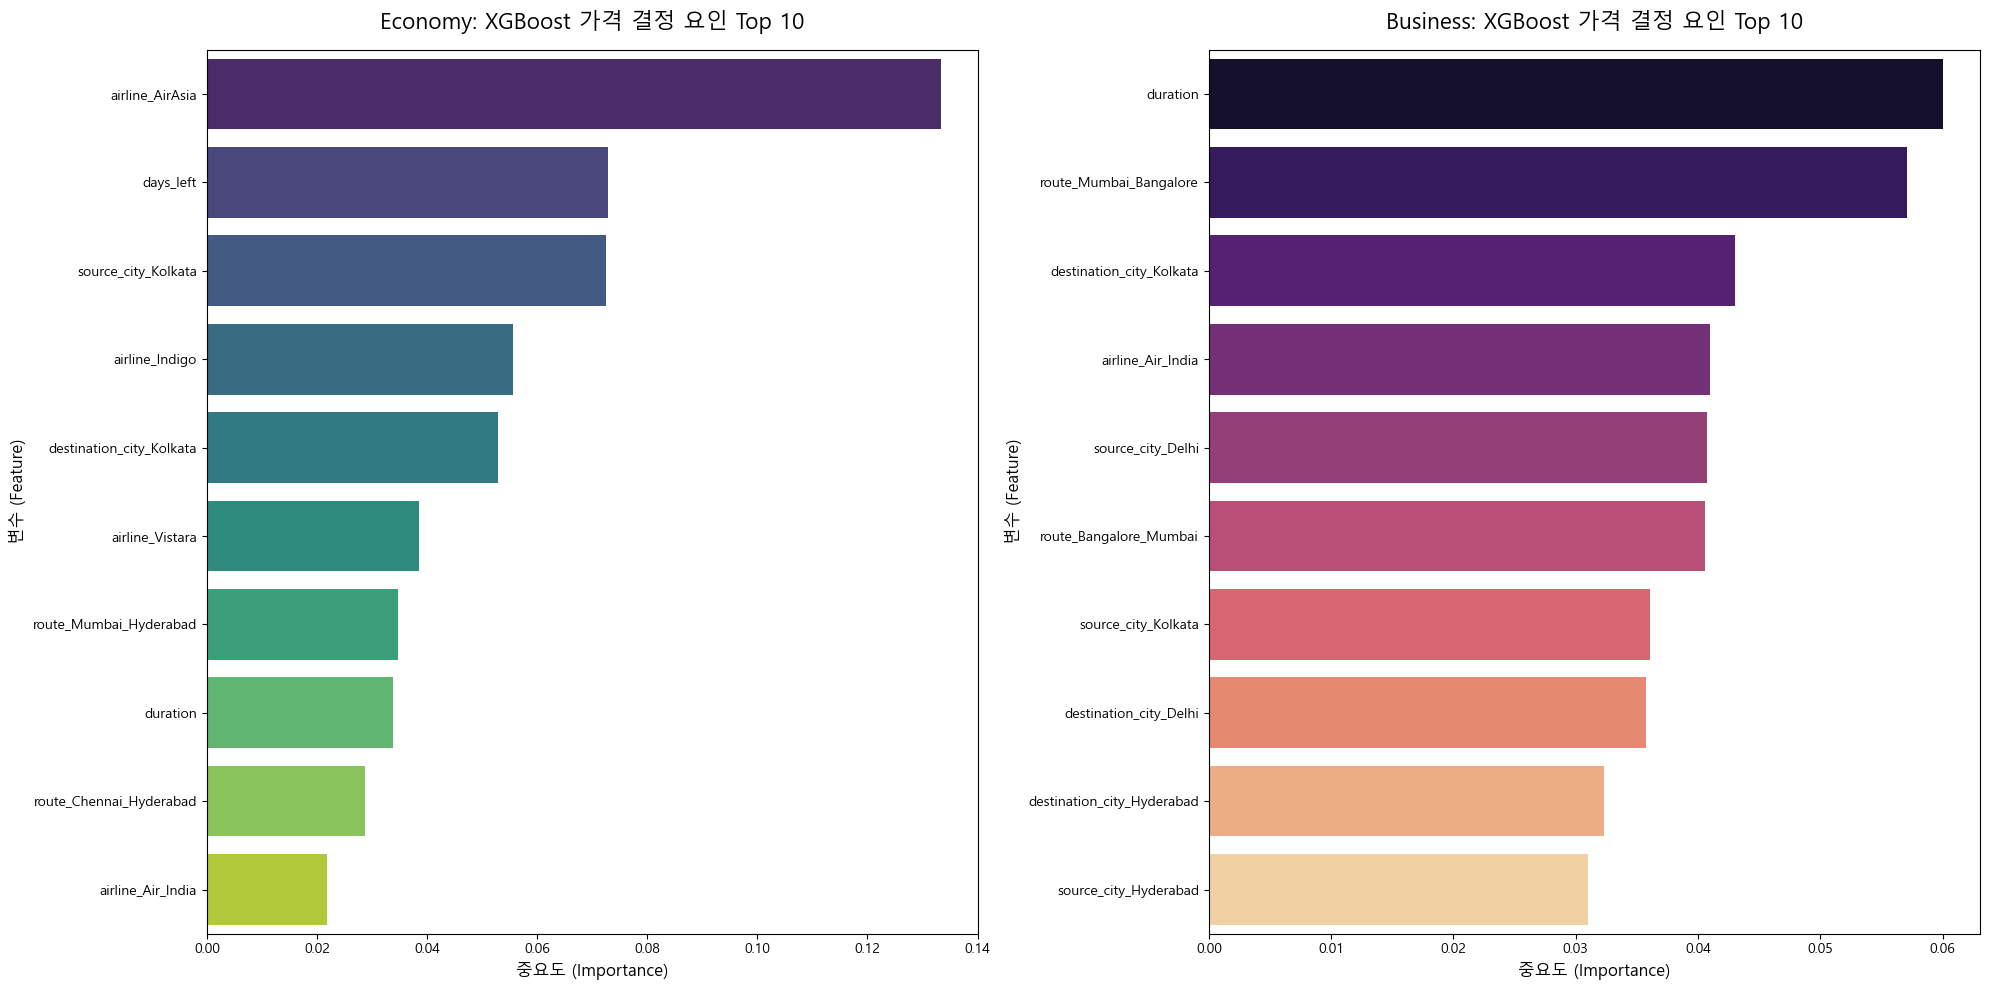

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. 한글 폰트 설정 (Windows 기준, 필수)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 2. 시각화 그리기 (이코노미, 비즈니스 나란히 배치)
plt.figure(figsize=(20, 10)) # 가로로 넓게 설정

# --- (왼쪽) Economy XGBoost 중요도 Top 10 ---
plt.subplot(1, 2, 1)
# 중요도 순으로 정렬 후 상위 10개 추출
xgb_eco_top10 = xgb_eco_imp.sort_values(by='Importance', ascending=False).head(10)

# 바 차트 그리ㅣ
sns.barplot(x='Importance', y='Feature', data=xgb_eco_top10, palette='viridis', hue='Feature', legend=False)
plt.title('Economy: XGBoost 가격 결정 요인 Top 10', fontsize=16, pad=15)
plt.xlabel('중요도 (Importance)', fontsize=12)
plt.ylabel('변수 (Feature)', fontsize=12)

# --- (오른쪽) Business XGBoost 중요도 Top 10 ---
plt.subplot(1, 2, 2)
# 중요도 순으로 정렬 후 상위 10개 추출
xgb_bus_top10 = xgb_bus_imp.sort_values(by='Importance', ascending=False).head(10)

# 바 차트 그리기
sns.barplot(x='Importance', y='Feature', data=xgb_bus_top10, palette='magma', hue='Feature', legend=False)
plt.title('Business: XGBoost 가격 결정 요인 Top 10', fontsize=16, pad=15)
plt.xlabel('중요도 (Importance)', fontsize=12)
plt.ylabel('변수 (Feature)', fontsize=12) # 오른쪽은 생략 가능

# 3. 레이아웃 조정 및 출력
plt.tight_layout()
plt.show()

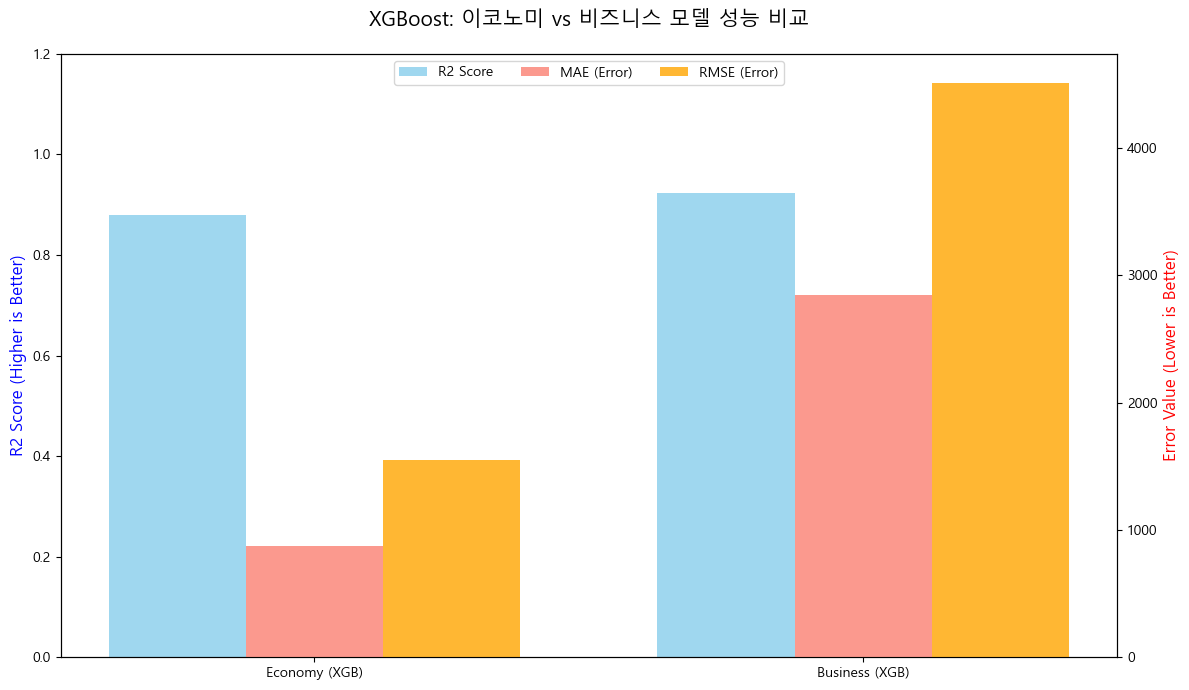

In [7]:
# --- 시각화: XGBoost 모델 성능 비교 ---
import matplotlib.pyplot as plt 
import seaborn as sns 

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

labels = ['Economy (XGB)', 'Business (XGB)']
r2_vals = [xgb_eco_r2, xgb_bus_r2]
mae_vals = [xgb_eco_mae, xgb_bus_mae]
rmse_vals = [xgb_eco_rmse, xgb_bus_rmse]

fig, ax1 = plt.subplots(figsize=(12, 7))
x = np.arange(len(labels))
width = 0.25 

# R2 Score (왼쪽 축)
rects1 = ax1.bar(x - width, r2_vals, width, label='R2 Score', color='skyblue', alpha=0.8)
ax1.set_ylabel('R2 Score (Higher is Better)', color='blue', fontsize=12)
ax1.set_ylim(0, 1.2)
ax1.set_xticks(x)
ax1.set_xticklabels(labels)

# MAE & RMSE (오른쪽 축)
ax2 = ax1.twinx()
rects2 = ax2.bar(x, mae_vals, width, label='MAE (Error)', color='salmon', alpha=0.8)
rects3 = ax2.bar(x + width, rmse_vals, width, label='RMSE (Error)', color='orange', alpha=0.8)
ax2.set_ylabel('Error Value (Lower is Better)', color='red', fontsize=12)

plt.title('XGBoost: 이코노미 vs 비즈니스 모델 성능 비교', fontsize=15, pad=20)

# 범례 통합
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper center', ncol=3)

plt.tight_layout()
plt.savefig('xgb_performance_comparison.png')
plt.show()

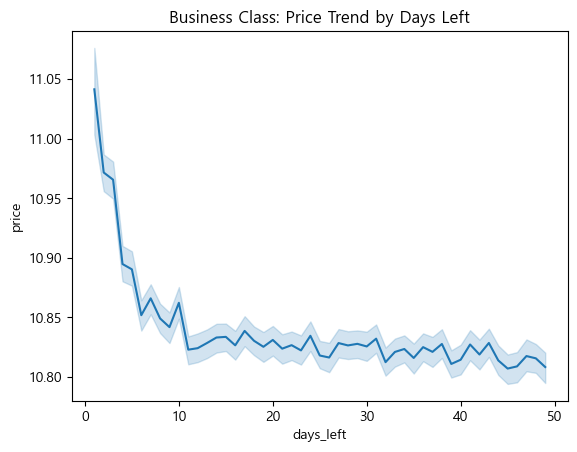

In [9]:
# 비즈니스석의 날짜별 가격 변동 그래프 확인
sns.lineplot(x='days_left', y='price', data=df[df['class']==1])
plt.title('Business Class: Price Trend by Days Left')
plt.show()

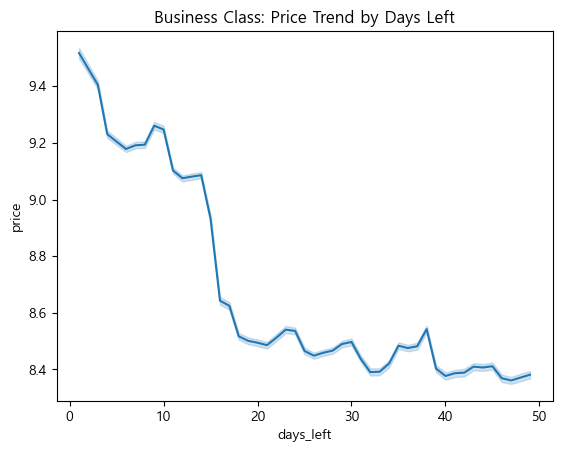

In [10]:
# 비즈니스석의 날짜별 가격 변동 그래프 확인
sns.lineplot(x='days_left', y='price', data=df[df['class']==0])
plt.title('Business Class: Price Trend by Days Left')
plt.show()

In [11]:
from sklearn.model_selection import GridSearchCV
import xgboost as xgb

# 1. 탐색할 파라미터 그리드 설정
# 너무 많이 넣으면 밤을 새야 하므로, 핵심적인 조합 12개로 압축했습니다.
param_grid = {
    'n_estimators': [500, 1000],          # 나무 개수 (충분한 학습량 확보)
    'max_depth': [4, 6],                  # 나무 깊이 (과적합 방지와 복잡도 사이의 균형)
    'learning_rate': [0.05, 0.1],         # 학습 속도
    'subsample': [0.8]                    # 데이터의 80%만 무작위 사용 (일반화 성능 향상)
}

# 2. 그리드 서치 함수 정의
def tune_xgb_model(target_df, label):
    X = pd.get_dummies(target_df.drop(columns=['price', 'class']))
    y = target_df['price']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # 기본 모델 설정
    xgb_model = xgb.XGBRegressor(random_state=42, n_jobs=-1)

    # GridSearchCV 설정 (cv=3으로 설정하여 속도와 검증의 균형을 맞춤)
    grid_search = GridSearchCV(estimator=xgb_model, 
                               param_grid=param_grid, 
                               cv=3, 
                               scoring='r2', 
                               verbose=1)

    print(f"--- {label} 모델 최적화 시작 ---")
    grid_search.fit(X_train, y_train)

    # 최적의 결과 출력
    print(f"최적 파라미터: {grid_search.best_params_}")
    
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)
    
    # 최종 성능 평가
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred))
    
    print(f"최종 R2: {r2:.4f}, MAE: {mae:.2f}\n")
    
    return best_model, r2, mae

# 3. 실행 (이코노미/비즈니스 각각 최적화)
# 데이터가 크므로 실행 시 시간이 몇 분 정도 소요될 수 있습니다.
best_xgb_eco, eco_r2_final, eco_mae_final = tune_xgb_model(df[df['class'] == 0], "Economy")
best_xgb_bus, bus_r2_final, bus_mae_final = tune_xgb_model(df[df['class'] == 1], "Business")

--- Economy 모델 최적화 시작 ---
Fitting 3 folds for each of 8 candidates, totalling 24 fits
최적 파라미터: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 1000, 'subsample': 0.8}
최종 R2: 0.9043, MAE: 760.61

--- Business 모델 최적화 시작 ---
Fitting 3 folds for each of 8 candidates, totalling 24 fits
최적 파라미터: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 1000, 'subsample': 0.8}
최종 R2: 0.9398, MAE: 2343.42



In [ ]:
from sklearn.model_selection import GridSearchCV
from lightgbm import LGBMRegressor

# 1. LightGBM용 파라미터 그리드 설정
lgbm_param_grid = {
    'n_estimators': [500, 1000],
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8],
    'random_state': [42],
    'force_col_wise': [True] # 대량 데이터 처리 시 메모리 효율을 위해 추가
}

# 2. 모델 최적화 함수 정의
def tune_lgbm_model(target_df, label):
    # 데이터 분리
    X = target_df.drop(columns=['price'])
    y = target_df['price'] # 이미 로그 변환된 상태
    
    X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # 기본 모델 생성
    lgbm_model = LGBMRegressor()

    # GridSearchCV 설정 (cv=3으로 속도 확보)
    grid_search = GridSearchCV(
        estimator=lgbm_model, 
        param_grid=lgbm_param_grid, 
        cv=3, 
        scoring='r2', 
        verbose=1
    )

    print(f"\n--- [{label}] LightGBM 최적화 시작 ---")
    grid_search.fit(X_train_l, y_train_l)

    # 최적 결과 저장
    best_params = grid_search.best_params_
    best_model = grid_search.best_estimator_
    
    # 예측 및 평가 (로그 스케일 기준)
    y_pred = best_model.predict(X_test_l)
    r2 = r2_score(y_test_l, y_pred)
    mae = mean_absolute_error(y_test_l, y_pred)
    
    print(f"최적 파라미터: {best_params}")
    print(f"최종 R2 Score: {r2:.4f}")
    print(f"최종 MAE (Log): {mae:.4f}")
    
    # 변수 중요도(Feature Importance) 데이터프레임 생성
    imp_df = pd.DataFrame({
        'Feature': X.columns, 
        'Importance': best_model.feature_importances_
    })
    
    return best_model, imp_df

# 3. 실행: 이코노미와 비즈니스 각각 최적화
best_lgbm_eco, lgbm_eco_imp = tune_lgbm_model(df_encoded[df_encoded['class'] == 0], "Economy")
best_lgbm_bus, lgbm_bus_imp = tune_lgbm_model(df_encoded[df_encoded['class'] == 1], "Business")